# 07. Post-modeling EDA -- disability strand



## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed")
OUTPUT_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs")
FIGURE_DIR = OUTPUT_DIR / 'post_eda_figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(OUTPUT_DIR / 'summary_full.csv')
top_activity = pd.read_csv(OUTPUT_DIR / 'top_activity_by_disability_group.csv')

with open(OUTPUT_DIR / 'fitted_models.pkl', 'rb') as f:
    fitted_models = pickle.load(f)
print('fitted models available:', list(fitted_models.keys()))


fitted models available: ['age_overall__Ridge Regression', 'age_overall__Random Forest', 'age_overall__Gradient Boosting', 'dis_overall__Ridge Regression', 'dis_overall__Random Forest', 'dis_overall__Gradient Boosting', 'dis_level__Ridge Regression', 'dis_level__Random Forest', 'dis_level__Gradient Boosting', 'months12__Ridge Regression', 'months12__Random Forest', 'months12__Gradient Boosting', 'days__Ridge Regression', 'days__Random Forest', 'days__Gradient Boosting', 'age_months12__Ridge Regression', 'age_months12__Random Forest', 'age_months12__Gradient Boosting', 'age_days__Ridge Regression', 'age_days__Random Forest', 'age_days__Gradient Boosting', 'age_level__Ridge Regression', 'age_level__Random Forest', 'age_level__Gradient Boosting']


## 1. Model comparison, one panel per task

One panel per task, ranking the four models by their own primary error metric
(total_variation for the composition tasks, mae for the single-rate tasks).


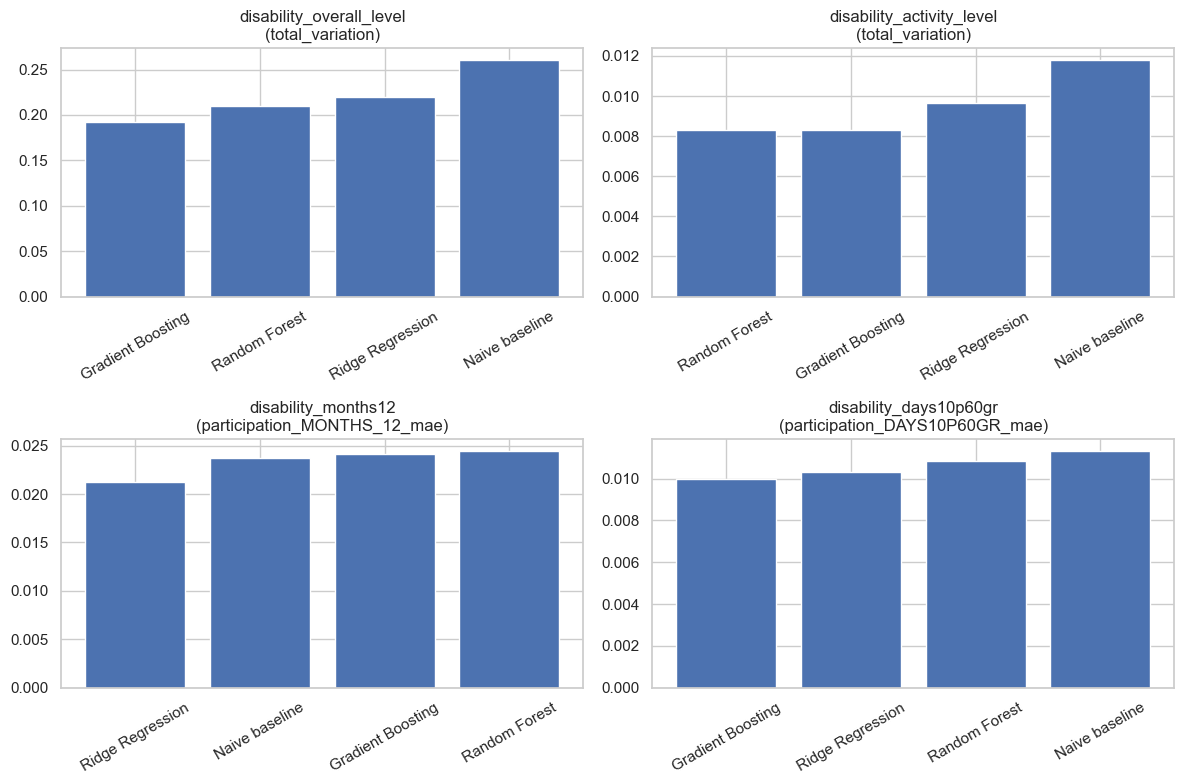

In [2]:
disability_tasks = {
    'disability_overall_level': 'total_variation',
    'disability_activity_level': 'total_variation',
    'disability_months12': 'participation_MONTHS_12_mae',
    'disability_days10p60gr': 'participation_DAYS10P60GR_mae',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for (task, metric), ax in zip(disability_tasks.items(), axes.ravel()):
    sub = summary[summary['task'] == task].sort_values(metric)
    ax.bar(sub['model'], sub[metric], color='#4C72B0')
    ax.set_title(f'{task}\n({metric})')
    ax.tick_params(axis='x', labelrotation=30)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_01_model_comparison.png', dpi=150)
plt.show()


## 2. Prediction error by borough



In [3]:
def add_lag_features(frame, panel_keys, value_cols, lag=1):
    prepared = frame.sort_values(panel_keys + ['year']).reset_index(drop=True)
    grouped = prepared.groupby(panel_keys, sort=False)
    for column in value_cols:
        prepared[f'{column}_lag{lag}'] = grouped[column].shift(lag)
    prepared['time_trend'] = prepared['year'] / prepared['year'].max()
    return prepared


def alr_to_shares(values):
    values = np.clip(np.asarray(values, dtype=float), -30, 30)
    exponent = np.exp(values)
    denominator = 1 + exponent.sum(axis=1, keepdims=True)
    return np.column_stack([exponent / denominator, 1 / denominator])


dis_level = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_all_years.csv')
dis_level['LA_2023'] = dis_level['LA_2023'].astype('Int64').astype(str)
target_cols = ['inactive_rate', 'fairly_active_rate', 'active_rate']
panel_keys = ['LA_2023', 'disability_group', 'activity']

prepared = add_lag_features(dis_level, panel_keys, target_cols, lag=1)
lag_cols = [f'{c}_lag1' for c in target_cols]
numeric = lag_cols + ['time_trend']
test = prepared[prepared['year'] == 8].dropna(subset=target_cols + lag_cols)

best_model = fitted_models['dis_level__Random Forest']  # swap the model name here if a different one won
predicted_shares = alr_to_shares(best_model.predict(test[numeric + panel_keys]))
test = test.copy()
test['predicted_active_rate'] = predicted_shares[:, 2]
test['abs_error'] = (test['active_rate'] - test['predicted_active_rate']).abs()


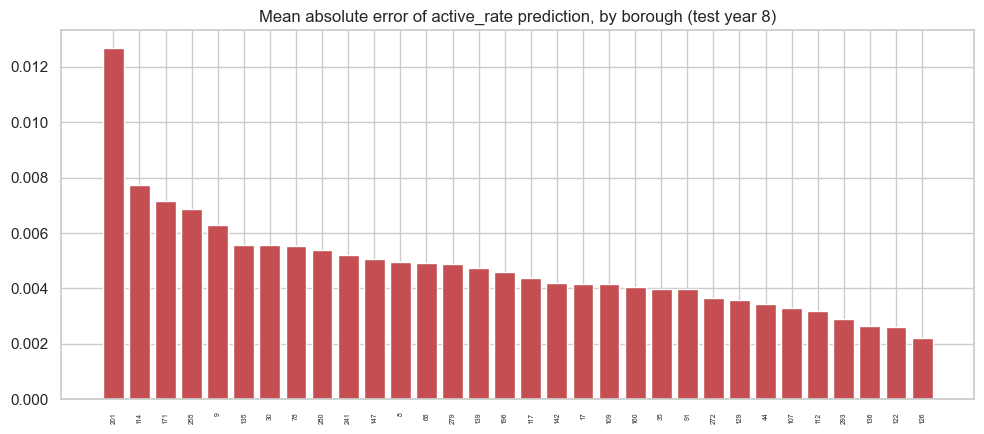

Boroughs with the largest prediction error:
LA_2023
201    0.012684
114    0.007727
171    0.007158
255    0.006872
9      0.006292
Name: abs_error, dtype: float64


In [4]:
error_by_borough = test.groupby('LA_2023')['abs_error'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(error_by_borough.index.astype(str), error_by_borough.values, color='#C44E52')
ax.set_title('Mean absolute error of active_rate prediction, by borough (test year 8)')
ax.tick_params(axis='x', labelrotation=90, labelsize=5)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_02_error_by_borough.png', dpi=150)
plt.show()

print('Boroughs with the largest prediction error:')
print(error_by_borough.head(5))


## 3. Prediction error by disability group


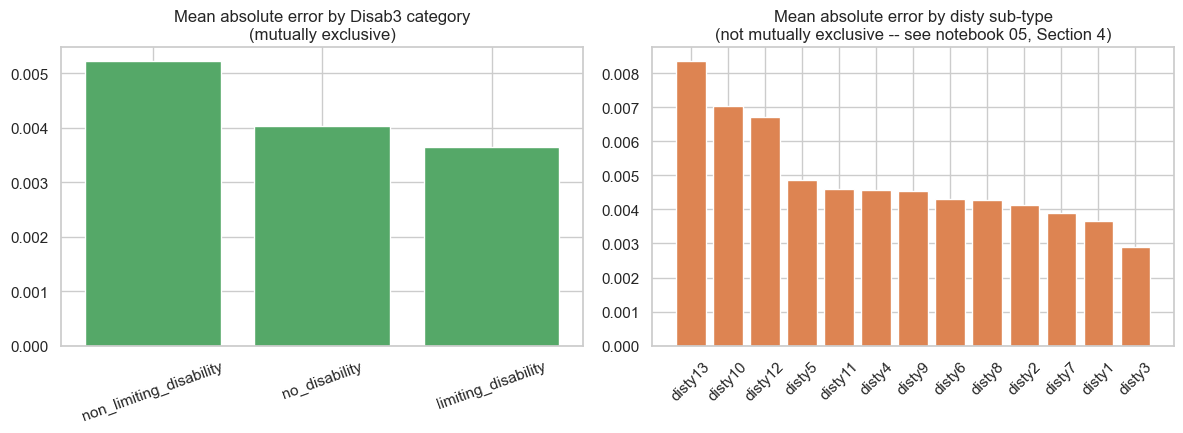

In [5]:
disab3_labels = {'limiting_disability', 'non_limiting_disability', 'no_disability'}
disty_labels = {f'disty{i}' for i in range(1, 14)}

error_by_group = test.groupby('disability_group')['abs_error'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

disab3_error = error_by_group[error_by_group.index.isin(disab3_labels)].sort_values(ascending=False)
axes[0].bar(disab3_error.index, disab3_error.values, color='#55A868')
axes[0].set_title('Mean absolute error by Disab3 category\n(mutually exclusive)')
axes[0].tick_params(axis='x', labelrotation=20)

disty_error = error_by_group[error_by_group.index.isin(disty_labels)].sort_values(ascending=False)
axes[1].bar(disty_error.index, disty_error.values, color='#DD8452')
axes[1].set_title('Mean absolute error by disty sub-type\n(not mutually exclusive -- see notebook 05, Section 4)')
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_03_error_by_disability_group.png', dpi=150)
plt.show()


## 4. Overall-level table vs activity-specific table


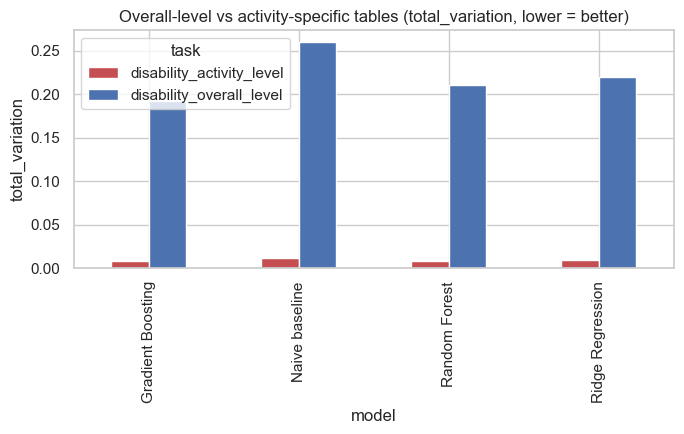

task               disability_activity_level  disability_overall_level
model                                                                 
Gradient Boosting                   0.008321                  0.192813
Naive baseline                      0.011798                  0.260630
Random Forest                       0.008305                  0.210276
Ridge Regression                    0.009668                  0.219942


In [6]:
compare_tasks = summary[summary['task'].isin(['disability_overall_level', 'disability_activity_level'])]
pivot = compare_tasks.pivot(index='model', columns='task', values='total_variation')

fig, ax = plt.subplots(figsize=(7, 4.5))
pivot.plot(kind='bar', ax=ax, color=['#C44E52', '#4C72B0'])
ax.set_title('Overall-level vs activity-specific tables (total_variation, lower = better)')
ax.set_ylabel('total_variation')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_04_overall_vs_activity_level.png', dpi=150)
plt.show()

print(pivot)


## 5. Most preferred activity, distribution across boroughs and groups


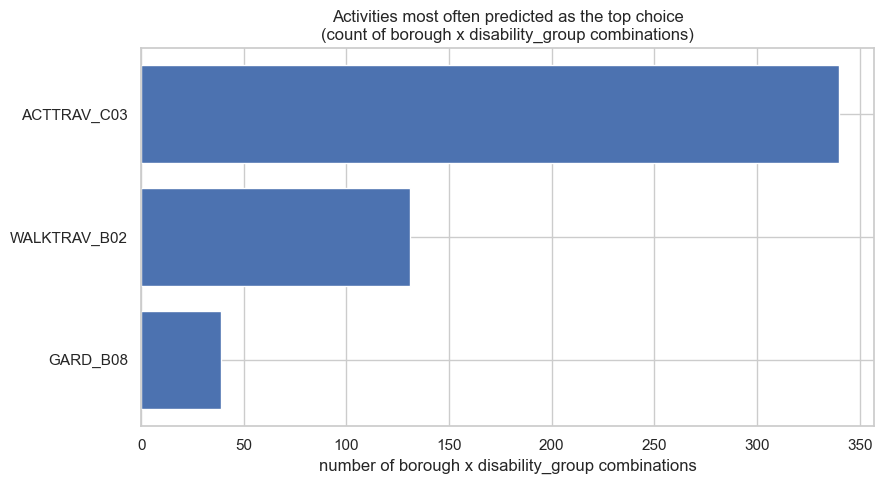

activity
ACTTRAV_C03     340
WALKTRAV_B02    131
GARD_B08         39
Name: count, dtype: int64


In [7]:
activity_win_counts = top_activity['activity'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(activity_win_counts.index[::-1], activity_win_counts.values[::-1], color='#4C72B0')
ax.set_title('Activities most often predicted as the top choice\n(count of borough x disability_group combinations)')
ax.set_xlabel('number of borough x disability_group combinations')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_05_top_activity_distribution.png', dpi=150)
plt.show()

print(activity_win_counts)


## 6. Forecast contrasts (statistical significance)

In [8]:
from scipy import stats

borough_201_errors = test[test['LA_2023'] == '201']['abs_error']
other_borough_errors = test[test['LA_2023'] != '201']['abs_error']

u_statistic, p_value = stats.mannwhitneyu(
    borough_201_errors, other_borough_errors, alternative='greater'
)
print(f'borough 201 vs rest: p={p_value:.4g}, n_201={len(borough_201_errors)}, n_rest={len(other_borough_errors)}')
print('median error, borough 201:', borough_201_errors.median())
print('median error, rest:', other_borough_errors.median())

borough 201 vs rest: p=0.5861, n_201=1875, n_rest=61011
median error, borough 201: 1.2672327629540968e-06
median error, rest: 1.2672327629540968e-06


In [9]:
non_limiting_errors = test[test['disability_group'] == 'non_limiting_disability']['abs_error']
limiting_errors = test[test['disability_group'] == 'limiting_disability']['abs_error']

u_statistic, p_value = stats.mannwhitneyu(
    non_limiting_errors, limiting_errors, alternative='greater'
)
print(f'non_limiting vs limiting: p={p_value:.4g}')
print('median error, non_limiting:', non_limiting_errors.median())
print('median error, limiting:', limiting_errors.median())

non_limiting vs limiting: p=0
median error, non_limiting: 1.2695422211746368e-06
median error, limiting: 1.2672327629540968e-06


In [10]:
dis_overall = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_overall_all_years.csv')
dis_overall['LA_2023'] = dis_overall['LA_2023'].astype('Int64').astype(str)
overall_target_cols = ['inactive_rate', 'fairly_active_rate', 'active_rate']
overall_prepared = add_lag_features(dis_overall, ['LA_2023', 'disability_group'], overall_target_cols, lag=1)
overall_lag_cols = [f'{c}_lag1' for c in overall_target_cols]
overall_numeric = overall_lag_cols + ['time_trend']
overall_test = overall_prepared[overall_prepared['year'] == 8].dropna(subset=overall_target_cols + overall_lag_cols)

overall_model = fitted_models['dis_overall__Random Forest']  # match whichever model won in section 4
overall_pred = alr_to_shares(overall_model.predict(overall_test[overall_numeric + ['LA_2023', 'disability_group']]))
overall_test = overall_test.copy()
overall_test['abs_error'] = (overall_test['active_rate'] - overall_pred[:, 2]).abs()

u_statistic, p_value = stats.mannwhitneyu(
    overall_test['abs_error'], test['abs_error'], alternative='greater'
)
print(f'overall-level error vs activity-level error: p={p_value:.4g}')
print('median error, overall-level:', overall_test['abs_error'].median())
print('median error, activity-level:', test['abs_error'].median())

overall-level error vs activity-level error: p=0
median error, overall-level: 0.1296766855315558
median error, activity-level: 1.2672327629540968e-06
